In [1]:
import json
import arviz as az
import pandas as pd
from IPython.display import display, Markdown
from matplotlib_inline.backend_inline import set_matplotlib_formats

from emu_renewal.constants import DATA_PATH, FULL_RUN
from emu_renewal.inputs import get_world_shp
from emu_renewal.outputs import get_param_vals_by_analysis, get_prop_better, get_median_scale_strength
from emu_renewal.plotting import plot_strength_evidence_map
from emu_renewal.utils import get_countries_by_continent, get_analysis_paths, get_analysis_commits_df, get_country_name

set_matplotlib_formats("svg")

# Purpose
This document presents the composite scaling strength
for the floored OxCGRT analysis,
$$
1 - f^{m},
$$
the fractional reduction in $M_t$ from unrestricted ($S_t=1$) to full restriction ($S_t=0$)
under
$$
M_t = [f + (1-f)\,S_t]^{m}.
$$
The table also records whether residual-process dispersion improved relative to
`no_scaling` (as in the dispersion comparisons document; yes if that probability exceeds 0.5).
The map colours countries by strength: red where dispersion improved,
grey where it did not. Countries without an estimate are hatched.


In [2]:
all_countries = json.load(open(DATA_PATH / "config/oxcgrt_included.json", "r"))
analysis_paths = get_analysis_paths(FULL_RUN, all_countries)
countries_by_cont = get_countries_by_continent(analysis_paths)
ordered_countries = [iso3 for iso3s in countries_by_cont.values() for iso3 in iso3s]

strengths = {}
prop_better = {}
for iso3 in ordered_countries:
    a_path = analysis_paths[iso3]["oxcgrt_floored"]
    strengths[iso3] = get_median_scale_strength(a_path)
    c_paths = {k: v for k, v in analysis_paths[iso3].items() if k in ("no_scaling", "oxcgrt_floored")}
    disp = get_param_vals_by_analysis("dispersion_proc", c_paths)
    prop_better[iso3] = get_prop_better(disp, "oxcgrt_floored", "no_scaling")

# Map of scaling strengths
The following map presents the median scaling strength value ($1-f^{m}$) 
for each country analysed as intensity of red colouring.
Countries for which there was no evidence of an improvement in the ease of 
fitting to data following the inclusion of policy effects are still displayed,
but the shading is shown in grey instead of red.

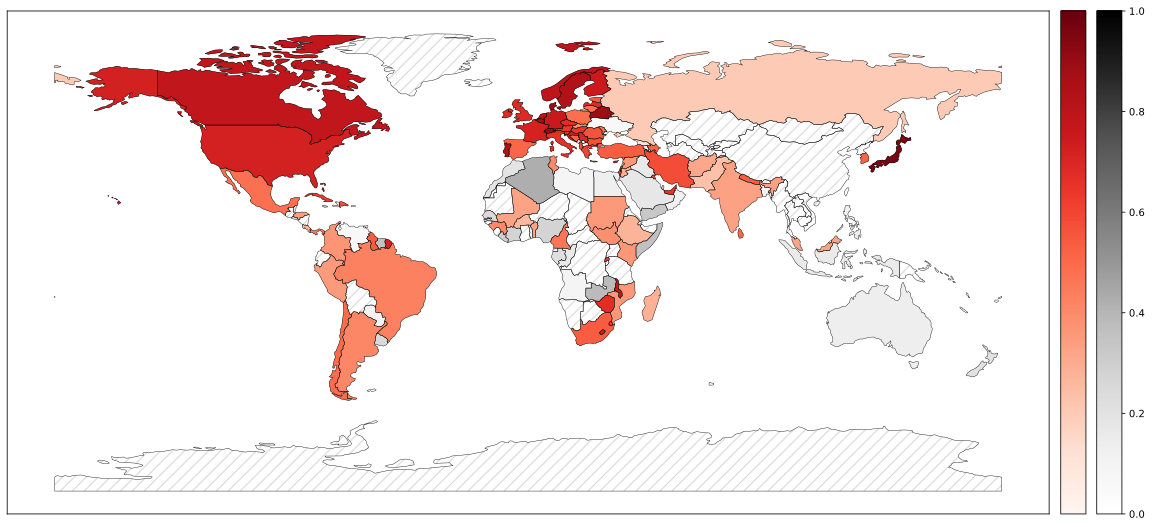

In [3]:
world = get_world_shp()
world["geometry"] = world.simplify(tolerance=0.1, preserve_topology=True)
world["strength"] = world["ISO_A3"].map(strengths)
supported = world[world["ISO_A3"].isin([i for i, p in prop_better.items() if p > 0.5])]
fig = plot_strength_evidence_map(world, "strength", 1.0, supported)
display(fig)

# Numerical results
The same numerical results as displayed in the above map are presented in
the following table, alongside an indication of whether ease of fitting
improved. This is indicated as "yes" or "no" based on whether more
than 50% of baseline runs showed a lower dispersion value than
a randomly selected run from the OxCGRT floored analysis approach.

In [4]:
strength_col = {"effect strength": pd.Series(strengths).map("{:.3f}".format)}
improved_col = {"dispersion improved": {i: "yes" if prop_better[i] > 0.5 else "no" for i in strengths}}
table = pd.DataFrame(strength_col | improved_col)
table.index = table.index.map(get_country_name)
display(Markdown(table.to_markdown(disable_numparse=True)))

|                                   | effect strength   | dispersion improved   |
|:----------------------------------|:------------------|:----------------------|
| Algeria                           | 0.423             | no                    |
| Angola                            | 0.090             | no                    |
| Benin                             | 0.324             | yes                   |
| Burkina Faso                      | 0.256             | yes                   |
| Cabo Verde                        | 0.515             | yes                   |
| Cameroon                          | 0.463             | yes                   |
| Congo                             | 0.158             | no                    |
| Côte d'Ivoire                     | 0.271             | no                    |
| Egypt                             | 0.132             | no                    |
| Eswatini                          | 0.619             | yes                   |
| Ethiopia                          | 0.271             | yes                   |
| Gabon                             | 0.220             | no                    |
| Guinea                            | 0.401             | yes                   |
| Kenya                             | 0.361             | yes                   |
| Lesotho                           | 0.727             | yes                   |
| Liberia                           | 0.295             | no                    |
| Libya                             | 0.084             | no                    |
| Madagascar                        | 0.284             | yes                   |
| Malawi                            | 0.779             | yes                   |
| Mali                              | 0.327             | yes                   |
| Morocco                           | 0.191             | no                    |
| Mozambique                        | 0.357             | yes                   |
| Nigeria                           | 0.272             | no                    |
| Rwanda                            | 0.637             | yes                   |
| Senegal                           | 0.249             | no                    |
| Somalia                           | 0.356             | no                    |
| South Africa                      | 0.533             | yes                   |
| South Sudan                       | 0.386             | yes                   |
| Sudan                             | 0.352             | yes                   |
| Togo                              | 0.124             | no                    |
| Tunisia                           | 0.397             | yes                   |
| Zambia                            | 0.383             | no                    |
| Zimbabwe                          | 0.675             | yes                   |
| Afghanistan                       | 0.309             | yes                   |
| Azerbaijan                        | 0.513             | yes                   |
| Bahrain                           | 0.263             | no                    |
| Bangladesh                        | 0.097             | no                    |
| Cyprus                            | 0.642             | yes                   |
| Georgia                           | 0.110             | yes                   |
| India                             | 0.329             | yes                   |
| Indonesia                         | 0.157             | no                    |
| Iran, Islamic Republic of         | 0.578             | yes                   |
| Iraq                              | 0.160             | no                    |
| Israel                            | 0.598             | yes                   |
| Japan                             | 0.961             | yes                   |
| Jordan                            | 0.280             | yes                   |
| Korea, Republic of                | 0.517             | yes                   |
| Kuwait                            | 0.565             | yes                   |
| Lebanon                           | 0.178             | yes                   |
| Malaysia                          | 0.322             | yes                   |
| Nepal                             | 0.535             | yes                   |
| Oman                              | 0.117             | no                    |
| Pakistan                          | 0.231             | yes                   |
| Palestine, State of               | 0.222             | no                    |
| Philippines                       | 0.125             | no                    |
| Qatar                             | 0.272             | yes                   |
| Saudi Arabia                      | 0.173             | no                    |
| Sri Lanka                         | 0.497             | yes                   |
| Syrian Arab Republic              | 0.354             | yes                   |
| Türkiye                           | 0.533             | yes                   |
| United Arab Emirates              | 0.655             | yes                   |
| Yemen                             | 0.325             | no                    |
| Albania                           | 0.577             | yes                   |
| Andorra                           | 0.949             | yes                   |
| Austria                           | 0.642             | yes                   |
| Belarus                           | 0.889             | yes                   |
| Belgium                           | 0.862             | yes                   |
| Bosnia and Herzegovina            | 0.522             | yes                   |
| Bulgaria                          | 0.569             | yes                   |
| Croatia                           | 0.704             | yes                   |
| Czechia                           | 0.676             | yes                   |
| Denmark                           | 0.888             | yes                   |
| Estonia                           | 0.538             | yes                   |
| Finland                           | 0.743             | yes                   |
| France                            | 0.714             | yes                   |
| Germany                           | 0.751             | yes                   |
| Greece                            | 0.599             | yes                   |
| Hungary                           | 0.646             | yes                   |
| Ireland                           | 0.683             | yes                   |
| Italy                             | 0.661             | yes                   |
| Kosovo                            | 0.710             | yes                   |
| Latvia                            | 0.678             | yes                   |
| Lithuania                         | 0.474             | yes                   |
| Luxembourg                        | 0.693             | yes                   |
| Malta                             | 0.587             | yes                   |
| Moldova, Republic of              | 0.449             | yes                   |
| Netherlands                       | 0.810             | yes                   |
| Norway                            | 0.791             | yes                   |
| Poland                            | 0.487             | yes                   |
| Portugal                          | 0.834             | yes                   |
| Romania                           | 0.561             | yes                   |
| Russian Federation                | 0.203             | yes                   |
| Serbia                            | 0.697             | yes                   |
| Slovakia                          | 0.377             | yes                   |
| Slovenia                          | 0.623             | yes                   |
| Spain                             | 0.508             | yes                   |
| Sweden                            | 0.834             | yes                   |
| Switzerland                       | 0.900             | yes                   |
| Ukraine                           | 0.062             | no                    |
| United Kingdom                    | 0.684             | yes                   |
| Aruba                             | 0.814             | yes                   |
| Bahamas                           | 0.793             | yes                   |
| Canada                            | 0.785             | yes                   |
| Costa Rica                        | 0.271             | yes                   |
| Cuba                              | 0.623             | yes                   |
| Dominican Republic                | 0.582             | yes                   |
| El Salvador                       | 0.223             | no                    |
| Haiti                             | 0.162             | no                    |
| Honduras                          | 0.339             | yes                   |
| Jamaica                           | 0.315             | no                    |
| Mexico                            | 0.483             | yes                   |
| Panama                            | 0.430             | yes                   |
| United States                     | 0.720             | yes                   |
| Australia                         | 0.136             | no                    |
| New Zealand                       | 0.203             | no                    |
| Singapore                         | 0.458             | yes                   |
| Argentina                         | 0.407             | yes                   |
| Brazil                            | 0.428             | yes                   |
| Chile                             | 0.495             | yes                   |
| Colombia                          | 0.366             | yes                   |
| Guyana                            | 0.532             | yes                   |
| Paraguay                          | 0.107             | no                    |
| Peru                              | 0.352             | yes                   |
| Suriname                          | 0.355             | no                    |
| Uruguay                           | 0.254             | no                    |
| Venezuela, Bolivarian Republic of | 0.056             | no                    |

In [5]:
Markdown(get_analysis_commits_df(analysis_paths).to_markdown())

|                                   | no scaling   | OxCGRT floored          | OxCGRT independent      | Google mobility   | Facebook tiles visited mobility   | Facebook single tile mobility   |
|:----------------------------------|:-------------|:------------------------|:------------------------|:------------------|:----------------------------------|:--------------------------------|
| Afghanistan                       | 4f57571      | b934196                 | b934196                 | b934196           | no analysis                       | no analysis                     |
| Albania                           | 4f57571      | b934196                 | b934196                 | no analysis       | b934196                           | b934196                         |
| Algeria                           | 4f57571      | b934196                 | b934196                 | no analysis       | b934196                           | b934196                         |
| Andorra                           | 4f57571      | b934196                 | b934196                 | no analysis       | no analysis                       | no analysis                     |
| Angola                            | 4f57571      | b934196                 | b934196                 | cb8324a           | cb8324a                           | cb8324a                         |
| Argentina                         | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Aruba                             | 4f57571      | b934196                 | b934196                 | 4f57571           | no analysis                       | no analysis                     |
| Australia                         | b934196      | b934196                 | b934196                 | no analysis       | no analysis                       | no analysis                     |
| Austria                           | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Azerbaijan                        | 4f57571      | b934196                 | b934196                 | no analysis       | no analysis                       | no analysis                     |
| Bahamas                           | 4f57571      | b934196                 | b934196                 | b934196           | no analysis                       | no analysis                     |
| Bahrain                           | 4f57571      | b934196                 | b934196                 | 4f57571           | no analysis                       | no analysis                     |
| Bangladesh                        | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Belarus                           | 4f57571      | b934196                 | b934196                 | cb8324a           | cb8324a                           | b934196                         |
| Belgium                           | 4f57571      | b934196                 | b934196                 | 4f57571           | 4f57571                           | 4f57571                         |
| Benin                             | 4f57571      | b934196                 | b934196                 | 4f57571           | 4f57571                           | b934196                         |
| Bosnia and Herzegovina            | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Brazil                            | 4f57571      | b934196                 | b934196                 | 4f57571           | 4f57571                           | 4f57571                         |
| Bulgaria                          | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Burkina Faso                      | 4f57571      | b934196                 | b934196                 | 4f57571           | 4f57571                           | 4f57571                         |
| Cabo Verde                        | 4f57571      | b934196                 | b934196                 | 4f57571           | no analysis                       | no analysis                     |
| Cameroon                          | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Canada                            | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Chile                             | 4f57571      | b934196                 | b934196                 | 4f57571           | b934196                           | b934196                         |
| Colombia                          | 4f57571      | b934196                 | b934196                 | 4f57571           | 4f57571                           | b934196                         |
| Congo                             | 4f57571      | b934196                 | b934196                 | no analysis       | 4f57571                           | b934196                         |
| Costa Rica                        | 4f57571      | b934196                 | b934196                 | 4f57571           | b934196                           | b934196                         |
| Croatia                           | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Cuba                              | 4f57571      | b934196                 | b934196                 | no analysis       | no analysis                       | no analysis                     |
| Cyprus                            | 4f57571      | b934196                 | b934196                 | no analysis       | no analysis                       | no analysis                     |
| Czechia                           | 4f57571      | b934196                 | b934196                 | 4f57571           | b934196                           | b934196                         |
| Côte d'Ivoire                     | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Denmark                           | 4f57571      | b934196                 | b934196                 | 4f57571           | 4f57571                           | 4f57571                         |
| Dominican Republic                | 4f57571      | b934196                 | b934196                 | 4f57571           | b934196                           | b934196                         |
| Egypt                             | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| El Salvador                       | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | 4f57571                           | 4f57571                         |
| Estonia                           | 4f57571      | b934196                 | b934196                 | 4f57571           | 4f57571                           | 4f57571                         |
| Eswatini                          | 4f57571      | 4c513a7                 | missing git information | no analysis       | no analysis                       | no analysis                     |
| Ethiopia                          | 4f57571      | b934196                 | b934196                 | no analysis       | b934196                           | b934196                         |
| Finland                           | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| France                            | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Gabon                             | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Georgia                           | 4f57571      | b934196                 | b934196                 | 4f57571           | b934196                           | b934196                         |
| Germany                           | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Greece                            | 4f57571      | b934196                 | b934196                 | 4f57571           | 4f57571                           | b934196                         |
| Guinea                            | 4f57571      | 4c513a7                 | b934196                 | no analysis       | b934196                           | b934196                         |
| Guyana                            | 4f57571      | b934196                 | b934196                 | no analysis       | 4f57571                           | 4f57571                         |
| Haiti                             | 4f57571      | b934196                 | 4c513a7                 | b934196           | b934196                           | b934196                         |
| Honduras                          | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Hungary                           | 4f57571      | b934196                 | b934196                 | 4f57571           | 4f57571                           | b934196                         |
| India                             | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Indonesia                         | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Iran, Islamic Republic of         | 4f57571      | b934196                 | b934196                 | no analysis       | no analysis                       | no analysis                     |
| Iraq                              | 4f57571      | b934196                 | b934196                 | 4f57571           | 4f57571                           | 4f57571                         |
| Ireland                           | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Israel                            | 4f57571      | b934196                 | b934196                 | b934196           | no analysis                       | no analysis                     |
| Italy                             | 4f57571      | b934196                 | b934196                 | 4f57571           | 4f57571                           | b934196                         |
| Jamaica                           | 4f57571      | b934196                 | cb8324a                 | b934196           | b934196                           | b934196                         |
| Japan                             | cb8324a      | cb8324a                 | cb8324a                 | cb8324a           | b934196                           | cb8324a                         |
| Jordan                            | 4f57571      | b934196                 | b934196                 | 4f57571           | 4f57571                           | 4f57571                         |
| Kenya                             | 4f57571      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Korea, Republic of                | 4f57571      | b934196                 | cb8324a                 | b934196           | b934196                           | cb8324a                         |
| Kosovo                            | 4f57571      | 4c513a7                 | 4c513a7                 | no analysis       | no analysis                       | no analysis                     |
| Kuwait                            | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | no analysis                       | no analysis                     |
| Latvia                            | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | 4f57571                           | 4f57571                         |
| Lebanon                           | 4f57571      | 4c513a7                 | b934196                 | 4f57571           | 4f57571                           | 4f57571                         |
| Lesotho                           | 4f57571      | b934196                 | 4c513a7                 | no analysis       | 4f57571                           | 4f57571                         |
| Liberia                           | 4f57571      | 4c513a7                 | 4c513a7                 | no analysis       | 4f57571                           | 4f57571                         |
| Libya                             | cb8324a      | b934196                 | cb8324a                 | cb8324a           | no analysis                       | no analysis                     |
| Lithuania                         | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | 4f57571                           | 4f57571                         |
| Luxembourg                        | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | cb8324a                           | cb8324a                         |
| Madagascar                        | 4f57571      | 4c513a7                 | 4c513a7                 | no analysis       | 4f57571                           | cb8324a                         |
| Malawi                            | 4f57571      | 4c513a7                 | cb8324a                 | no analysis       | cb8324a                           | cb8324a                         |
| Malaysia                          | 4f57571      | 1cab74a                 | 4c513a7                 | 4f57571           | 4f57571                           | 4f57571                         |
| Mali                              | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | 4f57571                           | 4f57571                         |
| Malta                             | cb8324a      | cb8324a                 | cb8324a                 | cb8324a           | cb8324a                           | cb8324a                         |
| Mexico                            | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | 4f57571                           | 4f57571                         |
| Moldova, Republic of              | 4f57571      | 4c513a7                 | 4c513a7                 | cb8324a           | cb8324a                           | cb8324a                         |
| Morocco                           | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | no analysis                       | no analysis                     |
| Mozambique                        | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | cb8324a                           | cb8324a                         |
| Nepal                             | 4f57571      | 4c513a7                 | 4c513a7                 | cb8324a           | cb8324a                           | cb8324a                         |
| Netherlands                       | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | cb8324a                           | cb8324a                         |
| New Zealand                       | 4c513a7      | 4c513a7                 | 4c513a7                 | no analysis       | no analysis                       | no analysis                     |
| Nigeria                           | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | 4f57571                           | 4f57571                         |
| Norway                            | 4f57571      | 4c513a7                 | 4c513a7                 | cb8324a           | cb8324a                           | cb8324a                         |
| Oman                              | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | 4f57571                           | 4f57571                         |
| Pakistan                          | 4f57571      | 4c513a7                 | cb8324a                 | cb8324a           | no analysis                       | no analysis                     |
| Palestine, State of               | cb8324a      | cb8324a                 | cb8324a                 | no analysis       | no analysis                       | no analysis                     |
| Panama                            | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | cb8324a                           | cb8324a                         |
| Paraguay                          | 4f57571      | 4c513a7                 | cb8324a                 | cb8324a           | cb8324a                           | cb8324a                         |
| Peru                              | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | 4f57571                           | 4f57571                         |
| Philippines                       | 4f57571      | 4c513a7                 | cb8324a                 | cb8324a           | cb8324a                           | cb8324a                         |
| Poland                            | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | 4f57571                           | cb8324a                         |
| Portugal                          | 4f57571      | 4c513a7                 | 4c513a7                 | cb8324a           | cb8324a                           | cb8324a                         |
| Qatar                             | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | 4f57571                           | 4f57571                         |
| Romania                           | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | cb8324a                           | cb8324a                         |
| Russian Federation                | 4f57571      | 4c513a7                 | cb8324a                 | cb8324a           | no analysis                       | no analysis                     |
| Rwanda                            | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | cb8324a                           | cb8324a                         |
| Saudi Arabia                      | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | 4f57571                           | cb8324a                         |
| Senegal                           | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | 4f57571                           | 4f57571                         |
| Serbia                            | 4f57571      | 4c513a7                 | 4c513a7                 | cb8324a           | cb8324a                           | cb8324a                         |
| Singapore                         | 4c513a7      | cb8324a                 | 4c513a7                 | no analysis       | no analysis                       | no analysis                     |
| Slovakia                          | cb8324a      | cb8324a                 | cb8324a                 | cb8324a           | cb8324a                           | cb8324a                         |
| Slovenia                          | cb8324a      | cb8324a                 | cb8324a                 | cb8324a           | cb8324a                           | cb8324a                         |
| Somalia                           | 4f57571      | 4c513a7                 | 4c513a7                 | no analysis       | no analysis                       | no analysis                     |
| South Africa                      | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | 4f57571                           | cb8324a                         |
| South Sudan                       | 4f57571      | cb8324a                 | cb8324a                 | no analysis       | no analysis                       | no analysis                     |
| Spain                             | cb8324a      | b934196                 | b934196                 | b934196           | b934196                           | b934196                         |
| Sri Lanka                         | cb8324a      | cb8324a                 | cb8324a                 | cb8324a           | cb8324a                           | b934196                         |
| Sudan                             | 4f57571      | 4c513a7                 | 4c513a7                 | no analysis       | no analysis                       | no analysis                     |
| Suriname                          | 4f57571      | 4c513a7                 | 4c513a7                 | no analysis       | 4f57571                           | 4f57571                         |
| Sweden                            | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | 4f57571                           | 4f57571                         |
| Switzerland                       | 4f57571      | b934196                 | b934196                 | 4f57571           | b934196                           | b934196                         |
| Syrian Arab Republic              | 4f57571      | cb8324a                 | cb8324a                 | no analysis       | no analysis                       | no analysis                     |
| Togo                              | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | 4f57571                           | 4f57571                         |
| Tunisia                           | 4f57571      | 4c513a7                 | 4c513a7                 | no analysis       | 4f57571                           | 4f57571                         |
| Türkiye                           | cb8324a      | cb8324a                 | cb8324a                 | cb8324a           | cb8324a                           | cb8324a                         |
| Ukraine                           | 4f57571      | missing git information | 4c513a7                 | 4f57571           | no analysis                       | no analysis                     |
| United Arab Emirates              | 4f57571      | b934196                 | b934196                 | 4f57571           | 4f57571                           | 4f57571                         |
| United Kingdom                    | 4f57571      | b934196                 | b934196                 | 4f57571           | b934196                           | b934196                         |
| United States                     | 4f57571      | 4c513a7                 | 4c513a7                 | cb8324a           | cb8324a                           | cb8324a                         |
| Uruguay                           | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | 4c513a7                           | 4f57571                         |
| Venezuela, Bolivarian Republic of | 4f57571      | 4c513a7                 | cb8324a                 | cb8324a           | no analysis                       | no analysis                     |
| Yemen                             | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | no analysis                       | no analysis                     |
| Zambia                            | cb8324a      | cb8324a                 | cb8324a                 | cb8324a           | cb8324a                           | cb8324a                         |
| Zimbabwe                          | 4f57571      | 4c513a7                 | 4c513a7                 | 4f57571           | cb8324a                           | cb8324a                         |